### Lab: Supervised land cover classification with Sentinel 2

In this lab, we'll compare several different traditional ML models applied to classifying Sentinel 2 data over Vienna, Austria in order to produce a forest cover map. You'll generate your own code based largely on [this lab from Project Pythia](https://projectpythia.org/eo-datascience-cookbook/notebooks/templates/classification/).

_Note: as in last week's lab, you'll want to use `dask` to speed up data loading. None of your cells should take longer than a minute to run, barring bad network connection. If you find that this is happening, in particular when calculating median composites, pause and double-check where you're calling `.compute()`. Feel free to check the solutions notebook if necessary._

In [1]:
# SETUP
from datetime import datetime, timedelta

import cmcrameri as cmc  # noqa: F401
import geopandas as gpd
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import odc.stac
import pandas as pd
import pystac_client
import rioxarray  # noqa: F401
import xarray as xr
from odc.geo.geobox import GeoBox
from shapely.geometry import Polygon
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from skimage.filters import threshold_otsu
import matplotlib.colors as mcolors

#### Part 1: Data Aquisition + Preprocessing
1. Following the code in the lab, pull Sentinel 2 data over Vienna from May of 2024. Load the data into an `xarray` dataset and visualize the RGB image and false color composite.

In [2]:
dx = 0.0006  # 60m resolution
epsg = 4326

# Set Spatial extent
latmin, latmax = 47.86, 48.407
lonmin, lonmax = 16.32, 16.9
bounds = (lonmin, latmin, lonmax, latmax)


# Set Temporal extent
start_date = datetime(year=2024, month=5, day=1)
end_date = start_date + timedelta(days=10)

time_format = "%Y-%m-%d"
date_query = start_date.strftime(time_format) + "/" + end_date.strftime(time_format)

# Search for Sentinel-2 data
items = (
    pystac_client.Client.open("https://earth-search.aws.element84.com/v1")
    .search(
        bbox=bounds,
        collections=["sentinel-2-l2a"],
        datetime=date_query,
        limit=100,
    )
    .item_collection()
)
print(len(items), "scenes found")

10 scenes found


In [3]:
# define a geobox for my region
geobox = GeoBox.from_bbox(bounds, crs=f"epsg:{epsg}", resolution=dx)

# lazily combine items into a datacube
dc = odc.stac.load(
    items,
    bands=["scl", "red", "green", "blue", "nir"],
    chunks={"time": 5, "x": 600, "y": 600},
    geobox=geobox,
    resampling="bilinear",
)
dc

<xarray.Dataset> Size: 79MB
Dimensions:      (latitude: 913, longitude: 967, time: 10)
Coordinates:
  * latitude     (latitude) float64 7kB 48.41 48.41 48.41 ... 47.86 47.86 47.86
  * longitude    (longitude) float64 8kB 16.32 16.32 16.32 ... 16.9 16.9 16.9
  * time         (time) datetime64[ns] 80B 2024-05-01T09:57:21.858000 ... 202...
    spatial_ref  int32 4B 4326
Data variables:
    scl          (time, latitude, longitude) uint8 9MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    red          (time, latitude, longitude) uint16 18MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    green        (time, latitude, longitude) uint16 18MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    blue         (time, latitude, longitude) uint16 18MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    nir          (time, latitude, longitude) uint16 18MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>

/Users/sujankakumanu/Documents/musa-650-spring2026/.venv/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


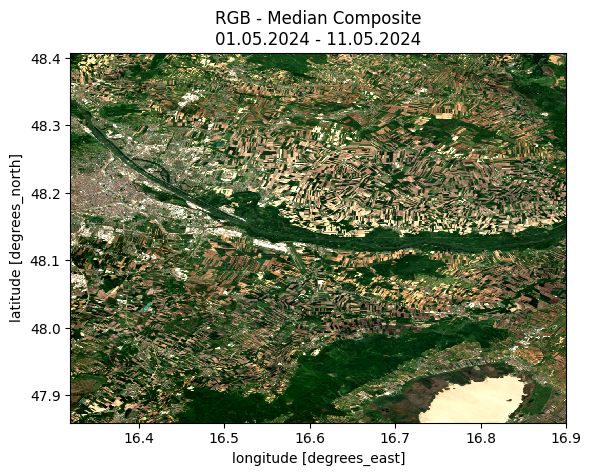

In [4]:
# define a mask for valid pixels (non-cloud)


def is_valid_pixel(data):
    # include only vegetated, not_vegitated, water, and snow
    return ((data > 3) & (data < 7)) | (data == 11)


dc["valid"] = is_valid_pixel(dc.scl)

# compute the masked median
rgb_median = (
    dc[["red", "green", "blue"]]
    .where(dc.valid)
    .to_dataarray(dim="band")
    .median(dim="time")
    .astype(int)
)

# plot the median composite
title_rgb = (
    "RGB - Median Composite"
    + f"\n{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
rgb_median.plot.imshow(robust=True).axes.set_title(title_rgb)
plt.show()

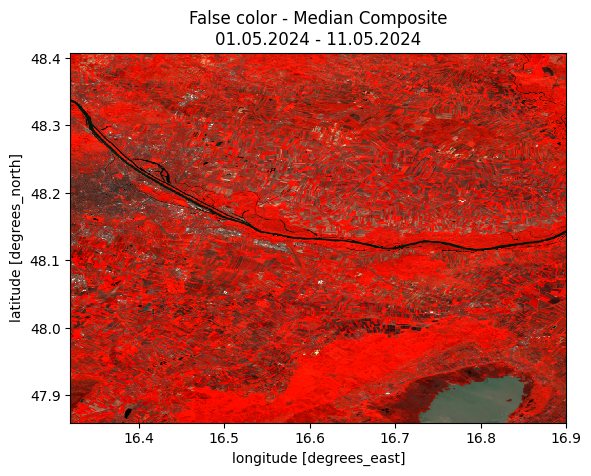

In [7]:
# compute a false color image
# near infrared instead of red
fc_median = (
    dc[["nir", "green", "blue"]]
    .where(dc.valid)
    .to_dataarray(dim="band")
    .transpose(..., "band")
    .median(dim="time")
    .astype(int)
)

title_fc = (
    "False color - Median Composite"
    + f"\n{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
fc_median.plot.imshow(robust=True).axes.set_title(title_fc)
plt.show()

#### Part 2: Baseline -- NDVI + Otsu's Method
2. Using the appropriate Sentinel 2 bands, calculate and plot NDVI for the image. Apply Otsu's method to produce a binary vegetation mask. Recall that our task for this lab is to classify _forest_ cover. Given the land cover in and around Vienna (take a look at your RGB image if you don't know what it looks like), why might NDVI + Otsu's rule not be appropriate here?

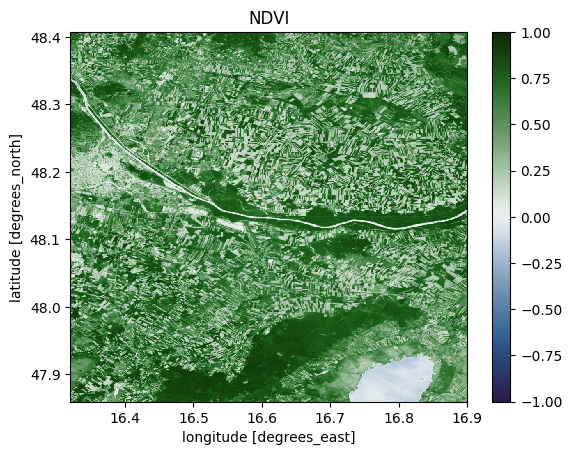

In [8]:
# Normalized Difference Vegetation Index (NDVI)


def normalized_difference(a, b):
    return (a - b * 1.0) / (a + b)


ndvi = normalized_difference(dc.nir, dc.red)
ndvi_median = ndvi.median(dim="time")
ndvi_median.plot.imshow(cmap="cmc.cork", vmin=-1, vmax=1).axes.set_title(
    "NDVI"
)
plt.show()

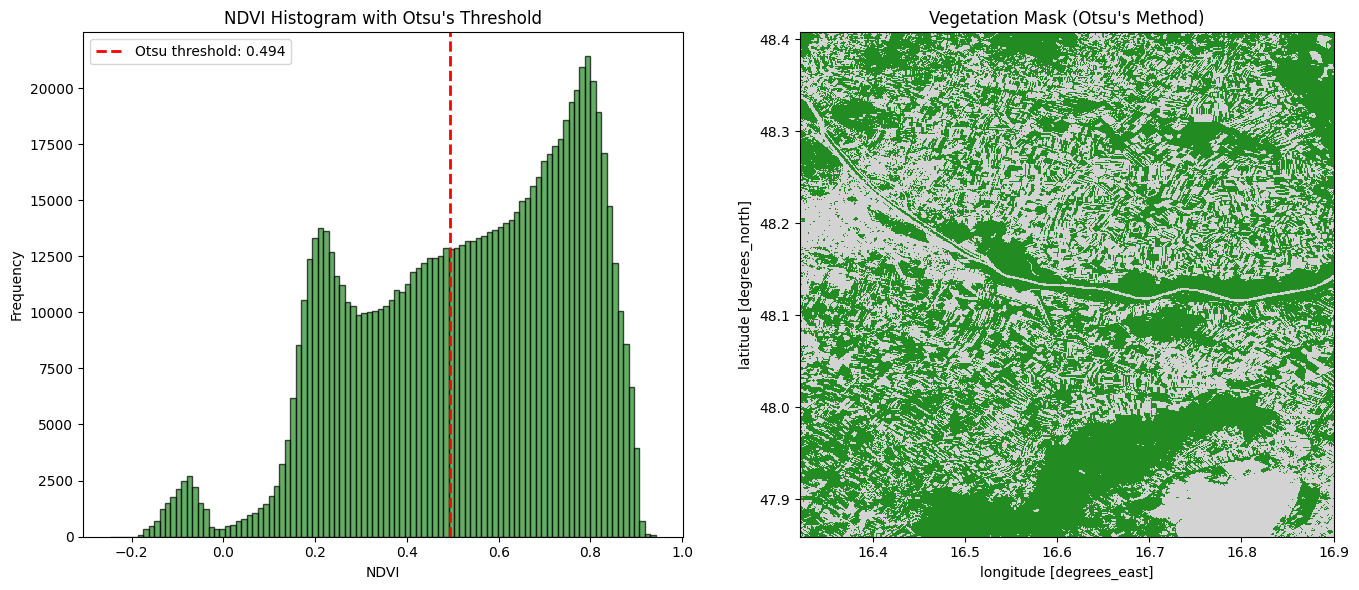

In [9]:
# OTSU
# Apply Otsu's method
ndvi_values = ndvi_median.values.flatten()
ndvi_valid = ndvi_values[~np.isnan(ndvi_values)]

otsu_threshold = threshold_otsu(ndvi_valid)

# Create binary mask
vegetation_mask_otsu = ndvi_median > otsu_threshold

# Plot the result
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with threshold
axes4[0].hist(ndvi_valid, bins=100, color="forestgreen", alpha=0.7, edgecolor="black")
axes4[0].axvline(
    otsu_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Otsu threshold: {otsu_threshold:.3f}",
)
axes4[0].set_xlabel("NDVI")
axes4[0].set_ylabel("Frequency")
axes4[0].set_title("NDVI Histogram with Otsu's Threshold")
axes4[0].legend()

# Binary mask
cmap_binary = mcolors.ListedColormap(["lightgray", "forestgreen"])
vegetation_mask_otsu.plot.imshow(ax=axes4[1], cmap=cmap_binary, add_colorbar=False)
axes4[1].set_title("Vegetation Mask (Otsu's Method)")
axes4[1].set_aspect("equal")

plt.tight_layout()

#### Part 3: Classification
3. Plot the training samples provided by the Project Pythia cookbook, as they do. Examine the polygons. What do you notice about their size, placement, and composition? How might this impact the results of our model? (Hint: what land cover classes does each polygon actually include?)

In [11]:
# Define Polygons
forest_areas = {
    0: [
        Polygon(
            [
                (16.482772, 47.901753),
                (16.465133, 47.870124),
                (16.510142, 47.874382),
                (16.482772, 47.901753),
            ]
        )
    ],
    1: [
        Polygon(
            [
                (16.594079, 47.938855),
                (16.581914, 47.894454),
                (16.620233, 47.910268),
                (16.594079, 47.938855),
            ]
        )
    ],
    2: [
        Polygon(
            [
                (16.67984, 47.978998),
                (16.637263, 47.971091),
                (16.660376, 47.929123),
                (16.67984, 47.978998),
            ]
        )
    ],
    3: [
        Polygon(
            [
                (16.756477, 48.000286),
                (16.723024, 47.983256),
                (16.739446, 47.972916),
                (16.756477, 48.000286),
            ]
        )
    ],
    4: [
        Polygon(
            [
                (16.80696, 48.135923),
                (16.780806, 48.125583),
                (16.798445, 48.115243),
                (16.80696, 48.135923),
            ]
        )
    ],
    5: [
        Polygon(
            [
                (16.684097, 48.144438),
                (16.664634, 48.124366),
                (16.690788, 48.118892),
                (16.684097, 48.144438),
            ]
        )
    ],
    6: [
        Polygon(
            [
                (16.550894, 48.169984),
                (16.530822, 48.165118),
                (16.558801, 48.137139),
                (16.550894, 48.169984),
            ]
        )
    ],
    7: [
        Polygon(
            [
                (16.588604, 48.402329),
                (16.556976, 48.401112),
                (16.580697, 48.382865),
                (16.588604, 48.402329),
            ]
        )
    ],
}

nonforest_areas = {
    0: [
        Polygon(
            [
                (16.674974, 48.269126),
                (16.623882, 48.236281),
                (16.682272, 48.213168),
                (16.674974, 48.269126),
            ]
        )
    ],
    1: [
        Polygon(
            [
                (16.375723, 48.228374),
                (16.357476, 48.188839),
                (16.399444, 48.185798),
                (16.375723, 48.228374),
            ]
        )
    ],
    2: [
        Polygon(
            [
                (16.457834, 48.26426),
                (16.418907, 48.267301),
                (16.440804, 48.23324),
                (16.457834, 48.26426),
            ]
        )
    ],
    3: [
        Polygon(
            [
                (16.519266, 48.101861),
                (16.470607, 48.100645),
                (16.500411, 48.07145),
                (16.519266, 48.101861),
            ]
        )
    ],
    4: [
        Polygon(
            [
                (16.453577, 48.051986),
                (16.412217, 48.067192),
                (16.425598, 48.012451),
                (16.453577, 48.051986),
            ]
        )
    ],
}

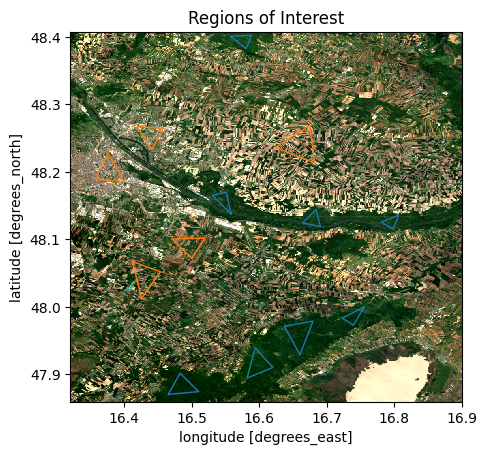

In [12]:
# Geoppandas Dataframe from Polygons
forest_df = gpd.GeoDataFrame(
    {"geometry": [poly[0] for poly in forest_areas.values()]}, crs="EPSG:4326"
)
nonforest_df = gpd.GeoDataFrame(
    {"geometry": [poly[0] for poly in nonforest_areas.values()]},
    crs="EPSG:4326",
)


# Plotting Regions of Interest
fig, ax = plt.subplots()
rgb_median.plot.imshow(ax=ax, robust=True)
forest_df.plot(ax=ax, ec="C0", fc="none")
nonforest_df.plot(ax=ax, ec="C1", fc="none")
ax.set_title("Regions of Interest")
ax.set_aspect("equal")
plt.show()


4. You'll be using the red, green, blue, and NIR bands for training and testing. Based on what you've learned in previous labs, why do you think we've selected these?


5. Split your data into training and testing sets (use a 70/30 split here, not 50/50 as the Project Pythia notebook does). Standardize your input features as we did in the previous week's lab. Since we're going to be training a linear classifier in addition to the naive Bayes and Random Forest, we'll need to standardize (although we wouldn't have to do this if we were just making the naive Bayes and Random Forest).


6. Train a linear classifier, naive Bayes, and Random Forest model. For each, examine the classification report, confusion matrix, and a map of the predictions.


7. Compare the results of each classifier. Which model is most accurate?


8. Map a 2x2 grid of the outputs of the threshold approach and all three classifiers. Following the Project Pythia cookbook, map a classification comparison of the threshold and each of the models (this should give you three such comparisons). Where does each model differ from the threshold? What types of pixels seem to generate disagreement?


9. Pick your most accurate model and add the NDVI as an additional feature. Retrain the model and test the model. Does performance improve? When you map the output, do you see any changes in the accuracy of the map, or in the areas that it classifies? Would you say that including NDVI as a feature improves performance?